In [22]:
import cfe
import scanpy as sc

cfe.settings.backend = "python_function"
cfe.logger.setLevel("DEBUG")

数据

In [23]:
adata = sc.read_h5ad("/home/huang/PyCode/scRNA/data/Pancreas/endocrinogenesis_day15.h5ad")
fadata = cfe.data.FateAnnData.from_anndata(adata)
fadata.layers["expression"] = fadata.layers["spliced"]
fadata.layers["count"] = fadata.layers["spliced"]

basis = "umap"

sc.pp.subsample(fadata, n_obs=500)

fadata

[2025年02月16日 20时19分48秒] DEBUG    Create a FateAnnData object from an existing AnnData object.                
                        DEBUG    Create a FateAnnData object from an existing AnnData object.                      


AnnData object with n_obs × n_vars = 500 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'cfe'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'count'

In [24]:
import pandas as pd

milestone_network = pd.DataFrame(
    data=[
        ["Ductal", "Ngn3 low EP"],
        ["Ngn3 low EP", "Ngn3 high EP"],
        ["Ngn3 high EP", "Pre-endocrine"],
        ["Pre-endocrine", "Alpha"],
        ["Pre-endocrine", "Beta"],
        ["Pre-endocrine", "Delta"],
        ["Pre-endocrine", "Epsilon"],
        ],
    columns=["from", "to"]
)

fadata.add_trajectory_mannually(milestone_network)

                        DEBUG    FateAnnData add_trajectory                                                        


/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/data/fate_anndata.py:244: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  milestone_emb = np.array(list(obs.groupby(cluster_key).apply(lambda x: X_emb[list(x.index)].mean(axis=0))))


/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/data/fate_anndata.py:508: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  group_df = self.milestone_wrapper.milestone_percentages.groupby("cell_id").apply(get_nearest_milestone)
/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/plot/plot_graph.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cell_emb_df = milestone_percentages.gro

[2025年02月16日 20时19分50秒] DEBUG    plot_trajectory                                                             


/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/plot/add_color.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cell_color_df = milestone_percentages.groupby("cell_id").apply(lambda mpg: mix_color(mpg))


[2025年02月16日 20时19分51秒] DEBUG    add waypoints                                                               
                        DEBUG    FateAnnData add_waypoints                                                         
                        DEBUG    add waypoints shape is (210, 500), finished!                                      


/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/data/fate_waypoint_wrapper.py:239: DeprecationWarning: Graph.shortest_paths() is deprecated; use Graph.distances() instead
  shortest_paths = gr.shortest_paths(source=waypoint_id_list, target=cell_id_list, weights="length", mode=mode)
/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/data/fate_waypoint_wrapper.py:94: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: group.assign(
/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/plot/plot_trajectory.py:155: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pand

AnnData object with n_obs × n_vars = 500 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'milestone_color', 'milestone'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'cfe', 'milestone_colors', 'milestone_color_colors'
    obsm: 'X_pca', 'X_umap', 'milestone_network_emb'
    layers: 'spliced', 'unspliced', 'expression', 'count'

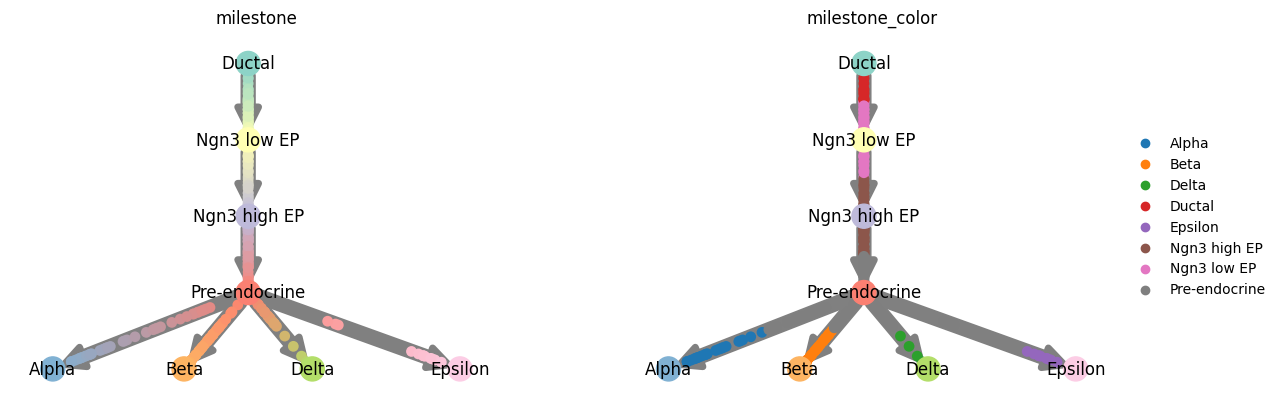

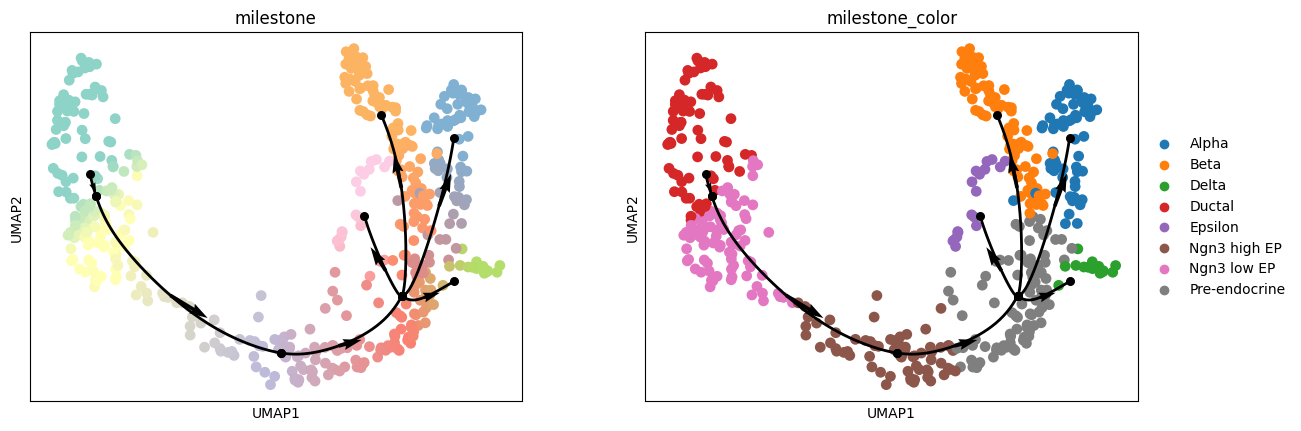

In [25]:
cluster_key = "milestone_color"
fadata.group_onto_nearest_milestones(cluster_key=cluster_key) # new cluster color

cluster_key_list = ["milestone", cluster_key]
cfe.plot.plot_graph(fadata, color=cluster_key_list)
cfe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list)
fadata

Method and plot

In [30]:
fadata.layers["expression"]

<500x27998 sparse matrix of type '<class 'numpy.float32'>'
	with 1250695 stored elements in Compressed Sparse Row format>

In [26]:
slingshot = cfe.method.FateMethod(method_name="slingshot", backend="dynverse_docker")

slingshot.infer_trajectory(fadata)

cfe.plot.plot_trajectory(fadata, basis="tsne", color=cluster_key_list)

[2025年02月16日 20时19分56秒] DEBUG    Docker image(dynverse/ti_slingshot:v1.0.3) loaded                           


                        INFO     method_backend: <cfe.method.fate_dynverse_docker_backend.DynverseDockerBackend    
                                 object at 0x79967c625c60>                                                         
                        WARNING                                                                                    
                                                 Prior information end_id,start_id is optional, but missing from   
                                 dataset 20250216_201948__FateAnnData__C6IC39DLTw.                                 
                                                                                                                   
                                                 Will not give this prior to method.                               
                                                                                                                   
                        DEBUG    Temp wd: /tmp/tmpd6o8j5xu              

AttributeError: 'NoneType' object has no attribute 'milestone_network'

In [15]:
# TODO: PAGA need to be optimized, disconnected graph
paga_method = cfe.method.FateMethod(method_name="paga")

prior_information = {
    "start_id": "C1",
    "groups_id": fadata.obs[cluster_key].tolist()
}
parameters = {"filter_features": False, "connectivity_cutoff": 0.05}
fadata.add_prior_information(**prior_information)  # add prior information to fadata
paga_method.infer_trajectory(fadata, parameters=parameters)

cfe.plot.plot_trajectory(fadata, basis="tsne", color=cluster_key_list)

[2025年02月16日 20时17分50秒] INFO     Loaded function: <function cf_paga at 0x799677a78280> from                  
                                       /home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/functi
                                       on/cf_paga.py                                                               
                        INFO     method_backend: <cfe.method.fate_function_backend.FunctionBackend object at       
                                 0x79967d741930>                                                                   
Normalized count data: X, spliced, unspliced.
Logarithmized X.


/home/huang/.conda/envs/cfe/lib/python3.10/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)


IndexError: index 0 is out of bounds for axis 0 with size 0

[2025年02月16日 20时18分07秒] INFO     Loaded function: <function cf_comp1 at 0x799677ef9ea0> from                 
                                       /home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/functi
                                       on/cf_comp1.py                                                              
                        INFO     method_backend: <cfe.method.fate_function_backend.FunctionBackend object at       
                                 0x79967c2fabf0>                                                                   


/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/plot/add_color.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cell_color_df = milestone_percentages.groupby("cell_id").apply(lambda mpg: mix_color(mpg))
/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/data/fate_waypoint_wrapper.py:239: DeprecationWarning: Graph.shortest_paths() is deprecated; use Graph.distances() instead
  shortest_paths = gr.shortest_paths(source=waypoint_id_list, target=cell_id_list, weights="length", mode=mode)
/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/data/fate_waypoint_wrapper.py:94: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavi

<Axes: title={'center': 'milestone_color'}, xlabel='UMAP1', ylabel='UMAP2'>

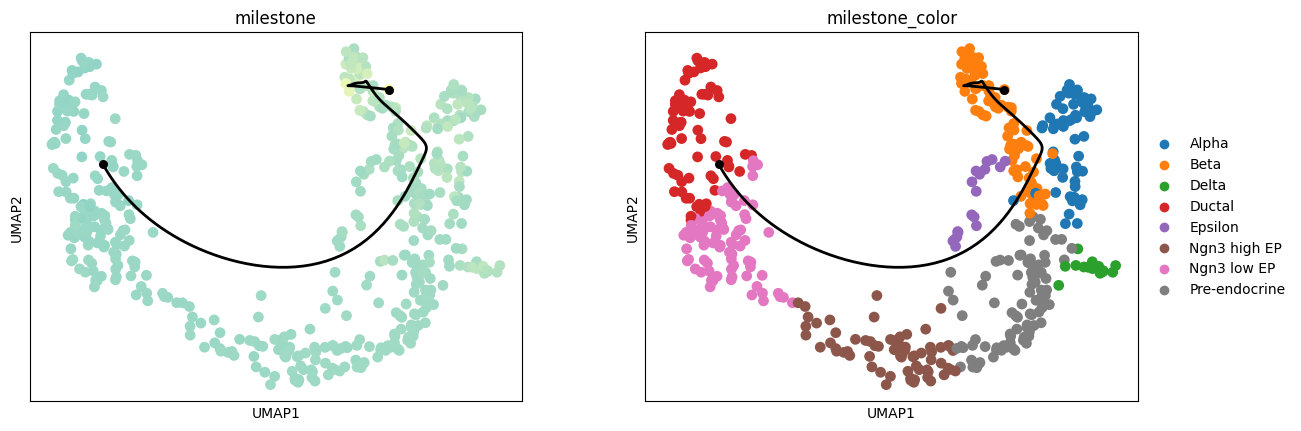

In [ ]:
comp1_method = cfe.method.FateMethod(method_name="comp1")

comp1_method.infer_trajectory(fadata)

cfe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list)

[2025年02月16日 20时23分48秒] DEBUG    FunctionBackend __init__                                                    
                        INFO     Loaded function: <function cf_mst at 0x79966c1f3490> from                         
                                 /home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/function/cf_
                                 mst.py                                                                            
                        INFO     method_backend: <cfe.method.fate_function_backend.FunctionBackend object at       
                                 0x79966fd15ae0>                                                                   
                        DEBUG    FateAnnData add_trajectory                                                        
                        DEBUG    plot_trajectory                                                                   


/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/method/function/cf_mst.py:45: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  centers = np.array(list(adata.obs.groupby(cluster_key).apply(lambda x: X_emb[list(x.index)].mean(axis=0))))
/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/plot/add_color.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  cell_color_df = milestone_percen

[2025年02月16日 20时23分49秒] DEBUG    add waypoints                                                               
                        DEBUG    FateAnnData add_waypoints                                                         
                        DEBUG    add waypoints shape is (210, 500), finished!                                      


/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/data/fate_waypoint_wrapper.py:239: DeprecationWarning: Graph.shortest_paths() is deprecated; use Graph.distances() instead
  shortest_paths = gr.shortest_paths(source=waypoint_id_list, target=cell_id_list, weights="length", mode=mode)
/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/data/fate_waypoint_wrapper.py:94: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: group.assign(
/home/huang/PyCode/scRNA/CellFateExplorer/CellFateExplorer/cfe/plot/plot_trajectory.py:155: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pand

<Axes: title={'center': 'milestone_color'}, xlabel='UMAP1', ylabel='UMAP2'>

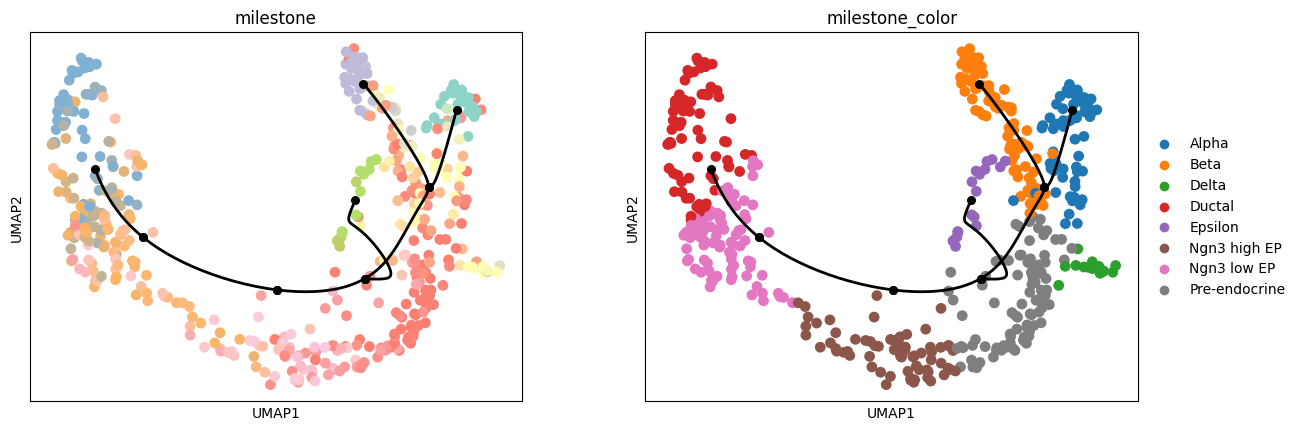

In [31]:
# TODO: MST need to be optimized
mst_method = cfe.method.FateMethod(method_name="mst", backend="python_function")

prior_information = {
    "groups_id": fadata.obs[cluster_key].tolist()
}
fadata.add_prior_information(**prior_information)  # add prior information to fadata

mst_method.infer_trajectory(fadata)

cfe.plot.plot_trajectory(fadata, basis=basis, color=cluster_key_list)

## 指标

In [ ]:
# parsed_model_name_list = fadata.get_all_model_name()
# model_name_list = fadata.get_all_model_name(parse=False)
# parsed_model_name_list, model_name_list
# # model_name_list = model_name_list[:-1] # TODO: 最后一个mst指标暂时会出错， 原因在于对于无向图的简化操作会报错

[2025年02月15日 17时29分19秒] WARNING  'ref' is not a valid random_time_string, don't need parse                   


(['ref',
  'slingshot-dynverse_docker',
  'paga-python_function',
  'comp1-python_function',
  'mst-python_function'],
 ['ref',
  '20250215_172823__slingshot-dynverse_docker__1o8Sk4PdBZ',
  '20250215_172838__paga-python_function__ND9D9apmaG',
  '20250215_172846__comp1-python_function__DYwrOuymLq',
  '20250215_172851__mst-python_function__vwp8pKDAkP'])

In [ ]:
# metrics = cfe.metric.metrics
# metric_id_list = metrics[metrics["category"] == "topology"]["metric_id"].tolist()
# metric_id_list

['edge_flip', 'him', 'isomorphic']

In [ ]:
# import pandas as pd


# model_metric_dict = {}

# for model_name in model_name_list:
#     model_metric = cfe.metric.calculate_metrics(
#         fadata,
#         metrics=metric_id_list,
#         now_model=model_name,
#         ref_model="ref"
#     )
#     model_metric_dict[model_name] = model_metric

# df = pd.DataFrame(model_metric_dict).T
# df

,isomorphic,edge_flip,him
ref,1,0,0
20250215_172823__slingshot-dynverse_docker__1o8Sk4PdBZ,1,0,0
20250215_172838__paga-python_function__ND9D9apmaG,0,0,0
20250215_172846__comp1-python_function__DYwrOuymLq,0,0,0
20250215_172851__mst-python_function__vwp8pKDAkP,1,0,0
